# Clustering

In [1]:
from warnings import filterwarnings

filterwarnings("ignore")

# if vs code is not performing auto completion
1. Open command pallete with Ctrl + Shift + P
2. Search Restart > Select Python Restart Language Server
 

# Step 1 - Data Ingestion

In [2]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Income,Spending
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Categorize similar customers based on Income and Spending

# Step 2 - perform basic data quality checks


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isna().sum()

CustomerID    0
Gender        0
Age           0
Income        0
Spending      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  200 non-null    int64 
 1   Gender      200 non-null    object
 2   Age         200 non-null    int64 
 3   Income      200 non-null    int64 
 4   Spending    200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Step 3 - Visualize scatter plot for income and spending

Text(0.5, 1.0, 'Income vs Spending')

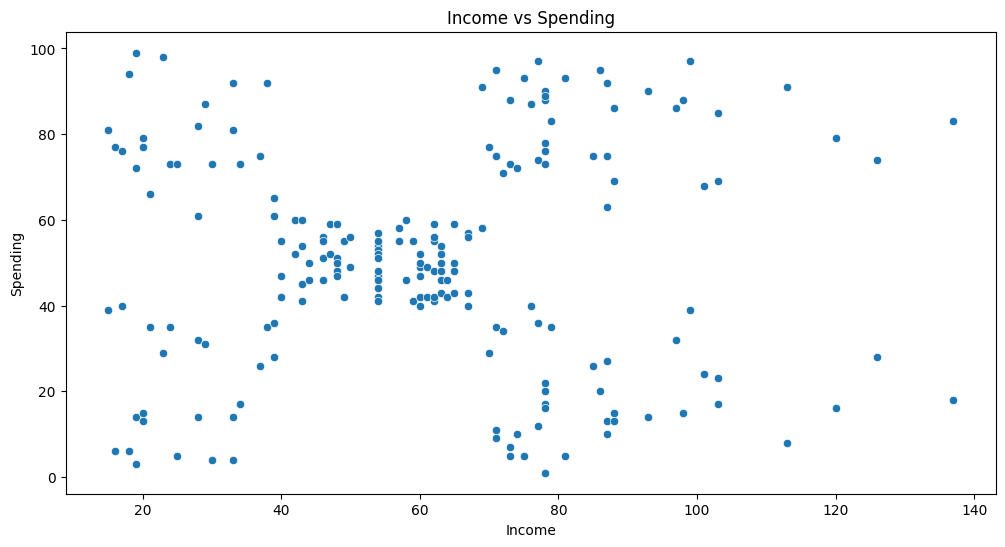

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="Income", y="Spending")
plt.title("Income vs Spending")

# Step 4 - Separate X(Income, Spending)

In [9]:
X = df[["Income", "Spending"]]

In [10]:
X.head()

,Income,Spending
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Step 5 - Apply Preprocessing on X

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [12]:
num_pipe = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler()).set_output(
    transform="pandas"
)

In [13]:
X_pre = num_pipe.fit_transform(X)

In [14]:
X_pre.head()

,Income,Spending
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [15]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


# Step 6 - Calculate optimum number of clusters using elbow method

In [16]:
!uv add kneed

Resolved 56 packages in 1.80s
Prepared 1 package in 164ms
Installed 1 package in 43ms
 + kneed==0.8.5


In [17]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [19]:
# Set the k values
K = range(1, 20)
# Initialize interias blank list
inertias = []

# Apply for loop on k
for i in K:
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_pre)
    a = km.inertia_
    print(f"Clusters : {i},Inertia : {a:.2f}")
    inertias.append(a)

Clusters : 1,Inertia : 400.00
Clusters : 2,Inertia : 273.67
Clusters : 3,Inertia : 157.70
Clusters : 4,Inertia : 109.23
Clusters : 5,Inertia : 65.57
Clusters : 6,Inertia : 60.13
Clusters : 7,Inertia : 49.67
Clusters : 8,Inertia : 37.32
Clusters : 9,Inertia : 32.50
Clusters : 10,Inertia : 30.06
Clusters : 11,Inertia : 26.76
Clusters : 12,Inertia : 26.23
Clusters : 13,Inertia : 23.19
Clusters : 14,Inertia : 21.20
Clusters : 15,Inertia : 18.18
Clusters : 16,Inertia : 16.08
Clusters : 17,Inertia : 15.24
Clusters : 18,Inertia : 14.62
Clusters : 19,Inertia : 13.89


In [20]:
knee = KneeLocator(K, inertias, curve="convex", direction="decreasing")
best_k = knee.elbow
print(f"best k value : {best_k}")

best k value : 5


In [21]:
inertias

[400.0,
 273.66888662642015,
 157.70400815035947,
 109.22822707921347,
 65.56840815571681,
 60.13287487193422,
 49.66824483736798,
 37.319122878338824,
 32.49508119910091,
 30.05932269404221,
 26.76120176636121,
 26.23289376978684,
 23.1935534219784,
 21.195257238649535,
 18.179104849335395,
 16.082488779041753,
 15.242557975456652,
 14.618057440193684,
 13.888437923082986]

# Plot the elbow curve

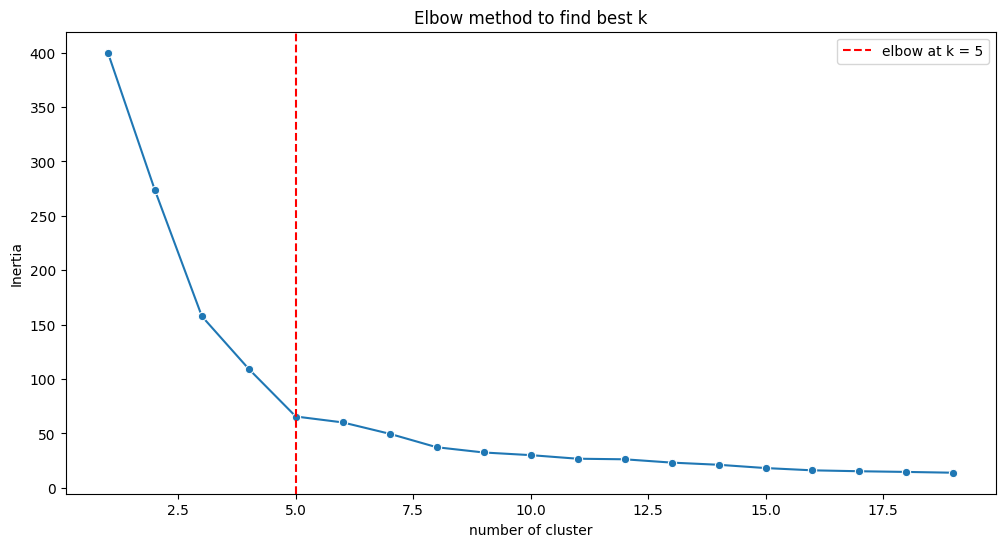

In [31]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=K, y=inertias, marker="o")
plt.axvline(x=best_k, color="red", linestyle="--", label=f"elbow at k = {best_k}")
plt.title("Elbow method to find best k")
plt.xlabel("number of cluster")
plt.ylabel("Inertia")
plt.legend()
plt.show()

# Step 6 - Build the Model

## Kmeans clustering

In [32]:
model_km = KMeans(n_clusters=best_k, random_state=42)
labels1 = model_km.fit_predict(X_pre)
labels1

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [33]:
X1 = X.copy()
X1.head()

,Income,Spending
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [34]:
X1["Labels"] = labels1

In [35]:
X1

,Income,Spending,Labels
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4
...,...,...,...
195,120,79,1
196,126,28,3
197,126,74,1
198,137,18,3


In [37]:
centroids1 = X1.groupby(by="Labels").mean()
centroids1

,Income,Spending
Labels,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


# Plot data after clustering

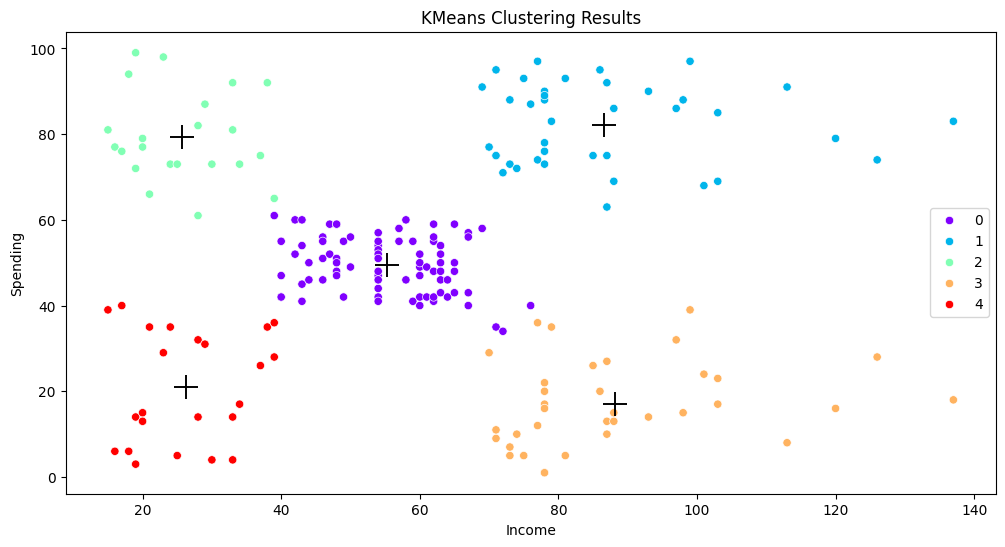

In [61]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=X1, x="Income", y="Spending", hue="Labels", palette="rainbow")
sns.scatterplot(
    data=centroids1, x="Income", y="Spending", color="black", marker="+", s=300
)
plt.title("KMeans Clustering Results")
plt.show()

# Agglomerative Clustering (Bottom Up Approach) 
- also called Hierchial

In [50]:
from sklearn.cluster import AgglomerativeClustering

agc_model = AgglomerativeClustering(n_clusters=best_k)
labels2 = agc_model.fit_predict(X_pre)

In [51]:
labels2

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [52]:
X2 = X.copy()

In [53]:
X2["labels"] = labels2

In [54]:
X2.head()

,Income,Spending,labels
0,15,39,4
1,15,81,3
2,16,6,4
3,16,77,3
4,17,40,4


In [55]:
for i in range(best_k):
    print(f"Cluster number: {i}")
    display(X2.query(f"labels :{labels2}"))

Cluster number: 0


ValueError: multi-line expressions are only valid in the context of data, use DataFrame.eval

In [56]:
centroids2 = X2.groupby(by="labels").mean()
centroids2

,Income,Spending
labels,,
0,89.406250,15.593750
1,86.538462,82.128205
2,55.811765,49.129412
3,25.095238,80.047619
4,26.304348,20.913043


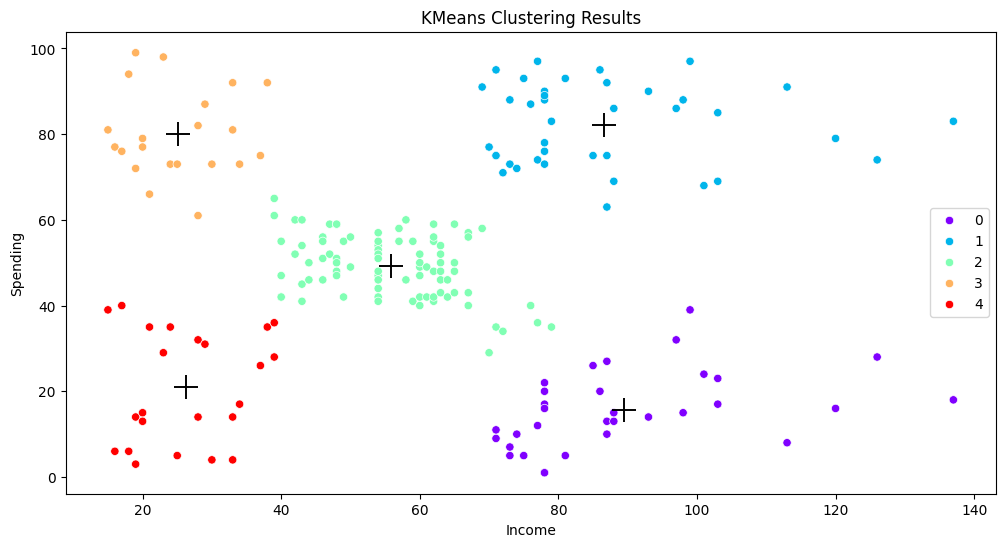

In [60]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=X2, x="Income", y="Spending", hue="labels", palette="rainbow")
sns.scatterplot(
    data=centroids2, x="Income", y="Spending", color="black", marker="+", s=300
)
plt.title("KMeans Clustering Results")
plt.show()